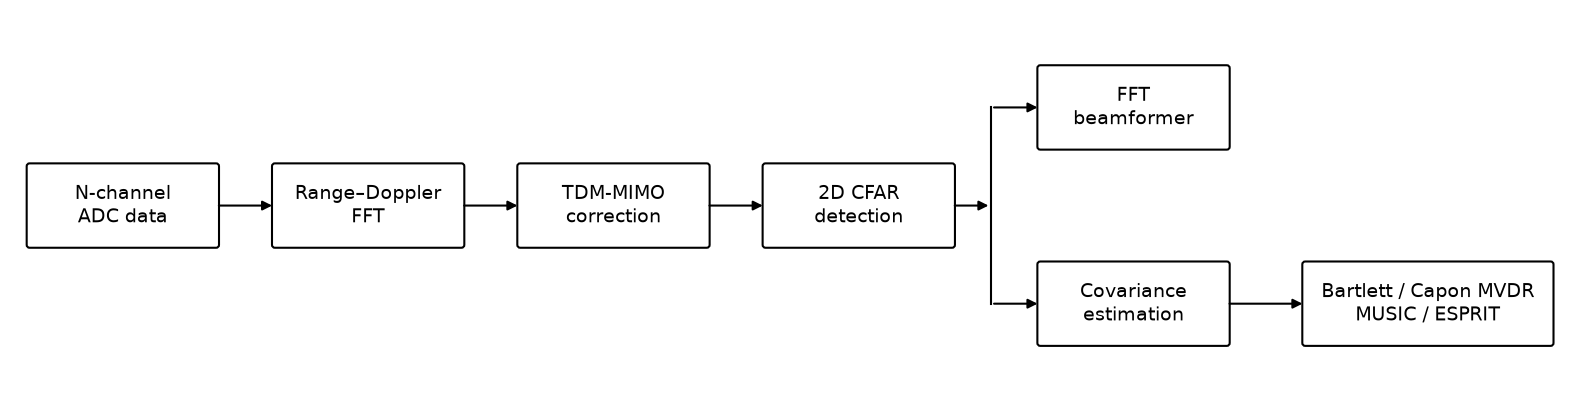

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def add_block(ax, x, y, width, height, text, fontsize=14):
    block = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black",
    )
    ax.add_patch(block)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
    )


def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.5,
        color="black",
    )
    ax.add_patch(arrow)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 4.5))

block_w = 1.9
block_h = 0.8

# Main FMCW processing chain
add_block(ax, 0.2, 1.8, block_w, block_h, "N-channel\nADC data")
add_block(ax, 2.7, 1.8, block_w, block_h, "Range–Doppler\nFFT")
add_block(ax, 5.2, 1.8, block_w, block_h, "TDM-MIMO\ncorrection")
add_block(ax, 7.7, 1.8, block_w, block_h, "2D CFAR\ndetection")

# DoA-processing branches
add_block(ax, 10.5, 2.8, block_w, block_h, "FFT\nbeamformer")
add_block(ax, 10.5, 0.8, block_w, block_h, "Covariance\nestimation")

add_block(
    ax,
    13.2,
    0.8,
    2.5,
    block_h,
    "Bartlett / Capon MVDR\nMUSIC / ESPRIT",
)

# Main-chain arrows
add_arrow(ax, (2.1, 2.2), (2.7, 2.2))
add_arrow(ax, (4.6, 2.2), (5.2, 2.2))
add_arrow(ax, (7.1, 2.2), (7.7, 2.2))

# Branch after CFAR detection
branch_x = 10.0

add_arrow(ax, (9.6, 2.2), (branch_x, 2.2))

ax.plot(
    [branch_x, branch_x],
    [1.2, 3.2],
    color="black",
    linewidth=1.5,
)

add_arrow(ax, (branch_x, 3.2), (10.5, 3.2))
add_arrow(ax, (branch_x, 1.2), (10.5, 1.2))

# Covariance-based DoA algorithms
add_arrow(ax, (12.4, 1.2), (13.2, 1.2))

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlim(0, 16)
ax.set_ylim(0.3, 4.2)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../docs/images/fmcw_mimo_doa_processing_chain.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()